## Steam trajectory - Data visualization

#### After ingesting all the data (the Kaggle set to get the cohort, Steamcharts scraping to get the data) and loading it into the notebook, let's visualize the data. We want to investigate the anomolous "earliest_month_tracked" field as well since it had 2 dates coming up frequently.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("/Users/pmacias/Dropbox/steamproject")
print(os.getcwd())

/Users/pmacias/Dropbox/steamproject


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from steam_trajectory.db.connection import get_connection

conn = get_connection("steam_project.db")

In [3]:
history_df = pd.read_sql("""
    SELECT g.appid, g.name, g.release_date,
           MIN(m.month) AS earliest_tracked_month
    FROM games g
    JOIN monthly_metrics m ON g.appid = m.appid
    GROUP BY g.appid
""", conn)

history_df["release_date_parsed"] = pd.to_datetime(history_df["release_date"], errors="coerce")
history_df["earliest_tracked_parsed"] = pd.to_datetime(history_df["earliest_tracked_month"], errors="coerce")
history_df["gap_months"] = (
    (history_df["earliest_tracked_parsed"] - history_df["release_date_parsed"])
    / pd.Timedelta(days=30.44)
).round(1)

print("Most common earliest_tracked_month values:")
print(history_df["earliest_tracked_month"].value_counts().head(10))

Most common earliest_tracked_month values:
earliest_tracked_month
2020-10-01    8
2022-04-01    8
2020-03-01    6
2021-11-01    6
2019-09-01    6
2020-09-01    6
2022-09-01    6
2019-01-01    5
2020-05-01    5
2019-04-01    5
Name: count, dtype: int64


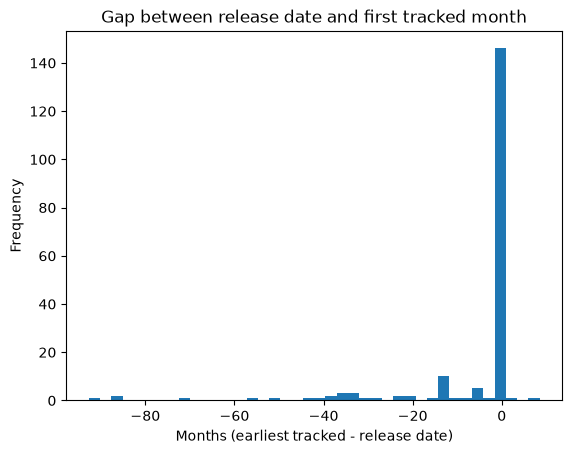

In [4]:
history_df["gap_months"].plot(kind="hist", bins=40, title="Gap between release date and first tracked month")
plt.xlabel("Months (earliest tracked - release date)")
plt.show()

In [5]:
large_gap = history_df[history_df["gap_months"] > 24].sort_values("gap_months", ascending=False)
print(f"{len(large_gap)} games with >24 month gap:")
large_gap[["name", "release_date", "earliest_tracked_month", "gap_months"]]

0 games with >24 month gap:


,name,release_date,earliest_tracked_month,gap_months


In [6]:
monthly_df = pd.read_sql("""
    SELECT appid, month, avg_players
    FROM monthly_metrics
    WHERE avg_players IS NOT NULL
    ORDER BY appid, month
""", conn)

monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df["month_index"] = monthly_df["month"].dt.year * 12 + monthly_df["month"].dt.month
monthly_df["months_since_start"] = monthly_df.groupby("appid")["month_index"].transform(lambda x: x - x.min())

In [7]:
completeness = monthly_df.groupby("appid")["months_since_start"].agg(["min", "max", "count"]).reset_index()
completeness["expected_months"] = completeness["max"] - completeness["min"] + 1
completeness["completeness_pct"] = completeness["count"] / completeness["expected_months"] * 100

print(completeness["completeness_pct"].describe())

count    189.000000
mean      93.763020
std       13.539290
min       32.352941
25%       95.652174
50%      100.000000
75%      100.000000
max      100.000000
Name: completeness_pct, dtype: float64


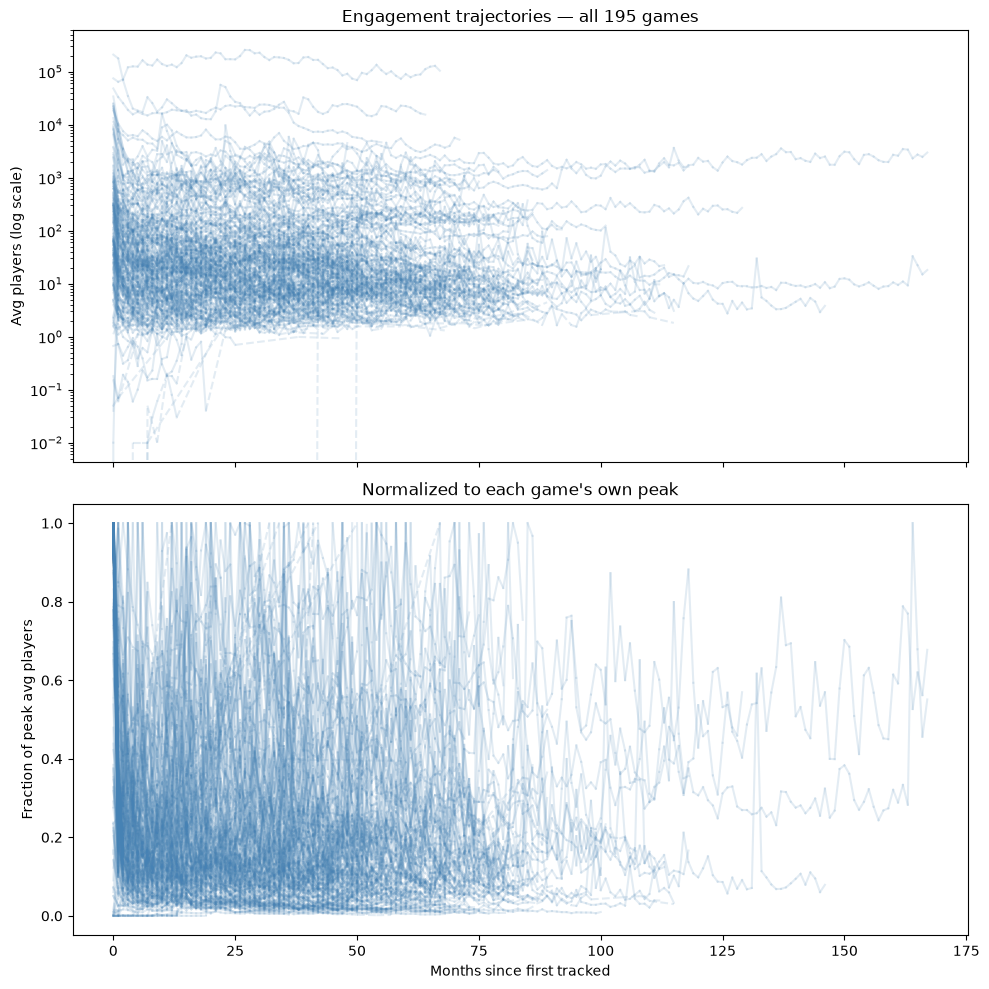

In [8]:
import numpy as np

def plot_with_gaps(ax, x, y, color, alpha):
    """Plots a single game's line, using a dashed segment anywhere
    the underlying months aren't consecutive (a real data gap) and
    a solid segment where they are — so a gap-bridging line reads
    visually as 'we don't know what happened here', not as a
    genuine observed trend."""
    x, y = np.asarray(x), np.asarray(y)
    order = np.argsort(x)
    x, y = x[order], y[order]
    for i in range(len(x) - 1):
        is_gap = (x[i + 1] - x[i]) > 1
        ax.plot(x[i:i+2], y[i:i+2], linestyle="--" if is_gap else "-",
                color=color, alpha=alpha)

peak_per_game = monthly_df.groupby("appid")["avg_players"].transform("max")
monthly_df["normalized_players"] = monthly_df["avg_players"] / peak_per_game

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

for appid, group in monthly_df.groupby("appid"):
    plot_with_gaps(ax1, group["months_since_start"], group["avg_players"], "steelblue", 0.15)
    plot_with_gaps(ax2, group["months_since_start"], group["normalized_players"], "steelblue", 0.15)

ax1.set_yscale("log")
ax1.set_ylabel("Avg players (log scale)")
ax1.set_title("Engagement trajectories — all 195 games")

ax2.set_ylabel("Fraction of peak avg players")
ax2.set_xlabel("Months since first tracked")
ax2.set_title("Normalized to each game's own peak")

plt.tight_layout()
plt.show()

In [9]:
db_appids = set(pd.read_sql("SELECT DISTINCT appid FROM monthly_metrics", conn)["appid"])
cohort_appids = set(pd.read_sql("SELECT appid FROM games", conn)["appid"])

print("Games table has:", len(cohort_appids), "games")
print("In monthly_metrics but not in games table:", db_appids - cohort_appids)
print("In games table but missing from monthly_metrics:", cohort_appids - db_appids)

Games table has: 189 games
In monthly_metrics but not in games table: set()
In games table but missing from monthly_metrics: set()


In [10]:
# For each game, find every month that's "near-peak" (within 90%
# of its own max) and see how spread out those near-peak months are
near_peak = monthly_df[monthly_df["normalized_players"] >= 0.9]
spread = near_peak.groupby("appid")["months_since_start"].agg(["count", "min", "max"])
spread["spread_months"] = spread["max"] - spread["min"]

# Bring in each game's actual peak avg_players, to test the
# low-count-noise theory directly
spread = spread.join(monthly_df.groupby("appid")["avg_players"].max().rename("peak_avg_players"))

# Sort by spread — the widest-spread "comb" offenders first
spread.sort_values("spread_months", ascending=False).head(15)

,count,min,max,spread_months,peak_avg_players
appid,,,,,
863590,2,12,75,63,130.39
983970,3,0,58,58,150.07
1606340,2,0,53,53,613.41
979060,7,15,57,42,150.29
1139890,4,1,30,29,44.94
1039880,6,16,42,26,33.25
601220,4,0,19,19,38.53
887570,2,35,52,17,420.36
1262350,2,0,16,16,270.06


count       189.000000
mean       4457.763545
std       24646.869404
min           3.950000
25%          44.940000
50%         169.940000
75%         829.280000
max      257416.670000
Name: avg_players, dtype: float64

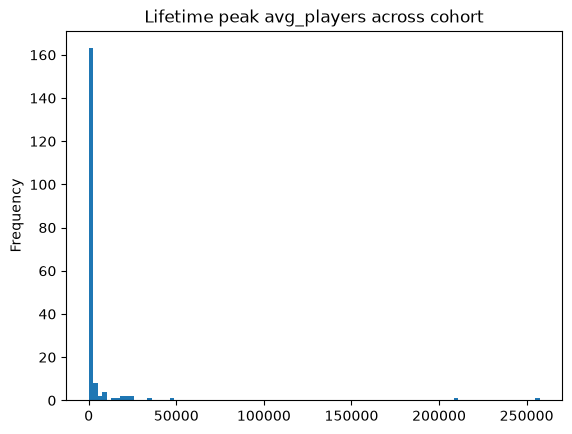

In [11]:
peak_lifetime = monthly_df.groupby("appid")["avg_players"].max()
peak_lifetime.plot(kind="hist", bins=100, title="Lifetime peak avg_players across cohort")
#plt.xlim(0,10000)
peak_lifetime.describe()


<Axes: xlabel='genre'>

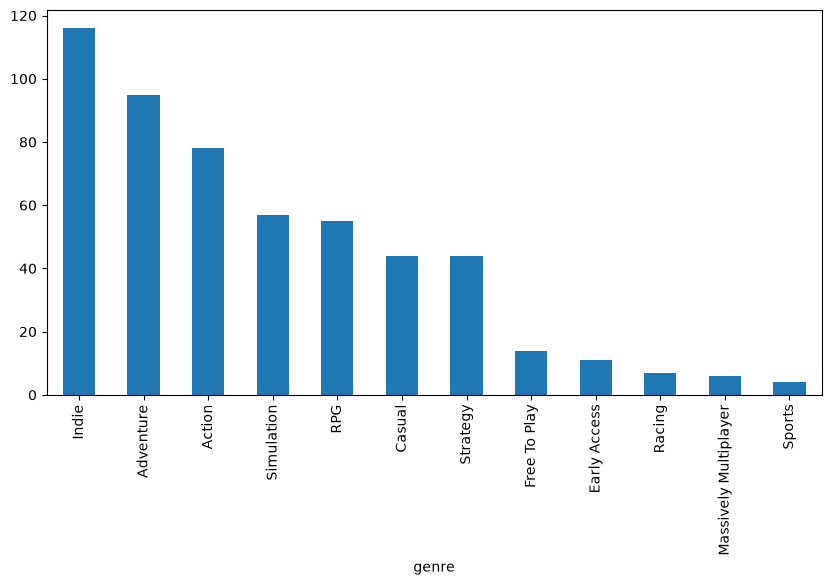

In [12]:
genre_counts = pd.read_sql("""
    SELECT gen.name AS genre, COUNT(*) as n
    FROM game_genres gg
    JOIN genres gen ON gg.genre_id = gen.genre_id
    GROUP BY gen.name
    ORDER BY n DESC
""", conn)
genre_counts.plot(kind="bar", x="genre", y="n", figsize=(10,5), legend=False)

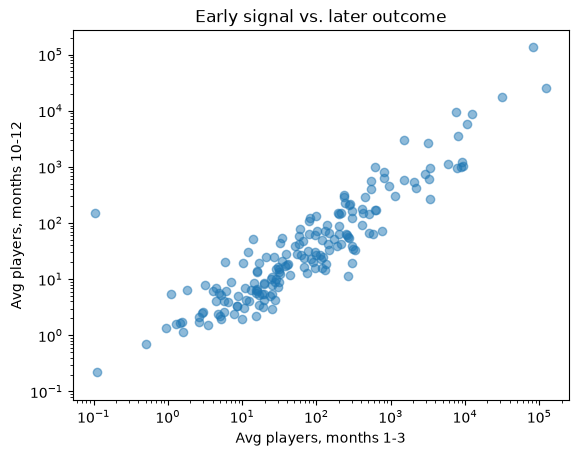

In [13]:
early = monthly_df[monthly_df["months_since_start"] <= 3].groupby("appid")["avg_players"].mean()
late = monthly_df[(monthly_df["months_since_start"] >= 10) & (monthly_df["months_since_start"] <= 12)].groupby("appid")["avg_players"].mean()

comparison = pd.DataFrame({"early": early, "late": late}).dropna()

fig, ax = plt.subplots()
ax.scatter(comparison["early"], comparison["late"], alpha=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Avg players, months 1-3")
ax.set_ylabel("Avg players, months 10-12")
ax.set_title("Early signal vs. later outcome")
plt.show()

In [14]:
non_game_flags = ["Design & Illustration", "Animation & Modeling", "Education",
                   "Utilities", "Web Publishing", "Photo Editing",
                   "Software Training", "Video Production"]

suspect = pd.read_sql(f"""
    SELECT DISTINCT g.name, gen.name AS genre
    FROM games g
    JOIN game_genres gg ON g.appid = gg.appid
    JOIN genres gen ON gg.genre_id = gen.genre_id
    WHERE gen.name IN ({",".join(f"'{g}'" for g in non_game_flags)})
""", conn)
suspect

,name,genre


In [15]:
full_genres = pd.read_sql("""
    SELECT g.name, GROUP_CONCAT(gen.name, ', ') AS all_genres
    FROM games g
    JOIN game_genres gg ON g.appid = gg.appid
    JOIN genres gen ON gg.genre_id = gen.genre_id
    WHERE g.name IN ('CatTuber', 'XSOverlay', 'ScreenPlay')
    GROUP BY g.name
""", conn)
full_genres


,name,all_genres
